# Leap Hand Model evaluation

In [ ]:
import mujoco
import numpy as np
import types
import xml.etree.ElementTree as ET

model_path = "leap_hand_model/right_hand.xml"
model = mujoco.MjModel.from_xml_path(model_path)

n_bodies = model.nbody
print("Number of bodies:", n_bodies)
print("Number of joints:", model.njnt)
parents = model.body_parentid  # shape (n_bodies,)
print("Body parent IDs:", parents)

try:
    sim = mujoco.MjSim(model)
except AttributeError:
    # Newer mujoco bindings use MjData; provide a lightweight sim-like wrapper
    data = mujoco.MjData(model)
    sim = types.SimpleNamespace(data=data)



Number of bodies: 18
Number of joints: 16
Body parent IDs: [ 0  0  1  2  3  4  1  6  7  8  1 10 11 12  1 14 15 16]


In [ ]:
import jax.numpy as jnp
num_nodes = model.njnt
print("Number of nodes (joints):", num_nodes)
#edges = jnp.array([[0,1],[1,2],[2,3],[4,5],[5,6],[6,7],[8,9],[9,10],[10,11],[12,13],[13,14],[14,15],[0,4],[4,8],[8,12]])  # shape (n_edges, 2)
edges = jnp.array([[0,1],[1,2],[2,3],[3,4],[0,5],[5,6],[6,7],[7,8],[0,9],[9,10],[10,11],[11,12],[0,13],[13,14],[14,15],[15,16]])  # shape (n_edges, 2)
senders = jnp.concatenate([edges[:, 0], edges[:,1]], axis=0)
print("Senders:", senders)
receivers = jnp.concatenate([edges[:, 1], edges[:,0]], axis=0)
print("Receivers:", receivers)


Number of nodes (joints): 16
Senders: [ 0  1  2  3  0  5  6  7  0  9 10 11  0 13 14 15  1  2  3  4  5  6  7  8
  9 10 11 12 13 14 15 16]
Receivers: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16  0  1  2  3  0  5  6  7
  0  9 10 11  0 13 14 15]


# Training Process


In [ ]:
import os
import gc
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.

#!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


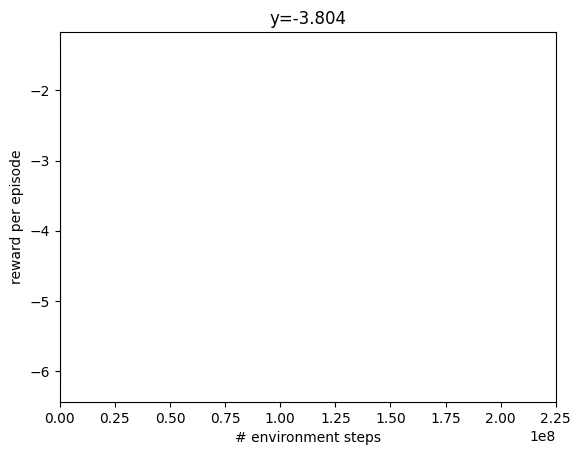

node feature example JitTracer<float32[17,2]>
node state vector shape: (128, 17, 64)
node feature example JitTracer<float32[256,17,2]>
node state vector shape: (40, 256, 17, 64)


In [ ]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
import network_brax as networks_brax
import ppo_networks_gnn as ppo_networks
from brax.training.agents.ppo import train as ppo
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp
from mujoco_playground import wrapper
from mujoco_playground import registry
from mujoco_playground.config import manipulation_params


env_name = 'LeapCubeRotateZAxis'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)
print("Observation size:", env.observation_size, "Action size:", env.action_size)
mj_model = env.mj_model

print(mj_model.nbody)

for i in range(mj_model.nbody):
    print(
        i,
        mujoco.mj_id2name(
            mj_model,
            mujoco.mjtObj.mjOBJ_BODY,
            i,
        ),
        mj_model.body_parentid[i],
    )
rng = jax.random.PRNGKey(0)
state = env.reset(rng)
#state = env.step(state, jp.zeros(env.action_size))
print(state.obs["privileged_state"])
print(state.obs["privileged_state"].shape)

data = state.data
print("position of palm:", data.qpos[0:3])
print("qpos", data.qpos.shape)
print("qvel", data.qvel.shape)

ppo_params = manipulation_params.brax_ppo_config(env_name)
ppo_params["num_timesteps"] = 180000000
ppo_params["num_envs"] = 128
ppo_params["num_evals"] = 15

ppo_params["network_factory"] = {"policy_hidden_layer_sizes": (128, 64)}

x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
#print("action size:", ppo_training_params["action_size"])

network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      edges=edges,
      policy_type = 'gnn', # mlp or gnn, mlp is baseline provided by brax
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress,
    #num_eval_envs=,
    seed=1
)

make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [ ]:
import pickle
from brax.training.agents.ppo import networks as ppo_networks
def save_checkpoint(path, params, ppo_params):
    checkpoint = {
        "params": params,
        "network_config": ppo_params.get("network_factory", {})
    }
    with open(path, "wb") as f:
        pickle.dump(checkpoint, f)


def load_policy(path, env):
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    params = checkpoint["params"]
    network_config = checkpoint["network_config"]
    networks = ppo_networks.make_ppo_networks(
        observation_size=env.observation_size,
        action_size=env.action_size,
        **network_config
    )

    inference_fn = ppo_networks.make_inference_fn(networks)
    return inference_fn(params, deterministic=True)

#save_checkpoint("gnn_model_4.pkl", params, ppo_params)

In [ ]:
import pickle

with open("gnn_model_3.pkl", "rb") as f:
    checkpoint = pickle.load(f)

print("Policy hidden layer sizes:", checkpoint["network_config"].policy_hidden_layer_sizes)
